In [1]:
# Cell 1: Setup and Imports
print("="*80)
print("🤖 MULTI-AGENT ORCHESTRATION FRAMEWORK")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Multi-Agent Orchestration environment ready")

# Import agent classes (will be defined in this notebook)
print("✅ Agent classes will be defined and orchestrated")

🤖 MULTI-AGENT ORCHESTRATION FRAMEWORK
✅ Multi-Agent Orchestration environment ready
✅ Agent classes will be defined and orchestrated


In [2]:
# Cell 2: Define Agent Classes
print("="*80)
print("🤖 DEFINING AGENT CLASSES")
print("="*80)

class ConservationAgent:
    """Conservation Agent - Animal Health Monitoring"""
    
    def __init__(self):
        self.name = "Conservation Agent"
        self.status = "active"
        self.alerts = []
    
    def monitor_animal(self, animal_data):
        """Monitor animal health"""
        # Simulated monitoring logic
        alert_probability = np.random.uniform(0, 0.3)
        is_alert = alert_probability > 0.2
        
        if is_alert:
            alert = {
                'agent': self.name,
                'type': 'animal_health_alert',
                'severity': 'high' if alert_probability > 0.25 else 'medium',
                'animal_id': animal_data.get('animal_id', 'unknown'),
                'message': f"Abnormal vitals detected for animal {animal_data.get('animal_id', 'unknown')}",
                'timestamp': datetime.now().isoformat()
            }
            self.alerts.append(alert)
            return alert
        return None
    
    def get_status(self):
        return {
            'name': self.name,
            'status': self.status,
            'active_alerts': len(self.alerts),
            'recent_alerts': self.alerts[-3:] if self.alerts else []
        }

class GuestExperienceAgent:
    """Guest Experience Agent - Personalization"""
    
    def __init__(self):
        self.name = "Guest Experience Agent"
        self.status = "active"
        self.recommendations = []
    
    def personalize(self, visitor_data):
        """Generate personalized recommendations"""
        ticket_type = visitor_data.get('ticket_type', 'Standard')
        age = visitor_data.get('age', 30)
        
        recommendations = []
        if ticket_type == 'VIP':
            recommendations = ["VIP Lounge Access", "Behind-the-scenes tour", "Complimentary dining"]
        elif ticket_type == 'Premium':
            recommendations = ["Priority queue access", "20% food discount", "Free photo"]
        else:
            recommendations = ["Free map", "Photo spots guide", "Show schedule"]
        
        if age < 18:
            recommendations.append("Kids activity pack")
        elif age > 60:
            recommendations.append("Senior discount")
        
        result = {
            'agent': self.name,
            'visitor_id': visitor_data.get('visitor_id', 'unknown'),
            'recommendations': recommendations[:3],
            'timestamp': datetime.now().isoformat()
        }
        self.recommendations.append(result)
        return result
    
    def get_status(self):
        return {
            'name': self.name,
            'status': self.status,
            'total_recommendations': len(self.recommendations),
            'recent': self.recommendations[-2:] if self.recommendations else []
        }

class CommercialAgent:
    """Commercial Agent - Revenue Optimization"""
    
    def __init__(self):
        self.name = "Commercial Agent"
        self.status = "active"
        self.optimizations = []
    
    def optimize(self, visitor_data):
        """Generate upselling recommendations"""
        predicted_spend = np.random.uniform(50, 200)
        
        if predicted_spend > 150:
            offer = "VIP upgrade - 30% off"
        elif predicted_spend > 80:
            offer = "Premium dining package - $25"
        else:
            offer = "Snack combo - $10"
        
        result = {
            'agent': self.name,
            'visitor_id': visitor_data.get('visitor_id', 'unknown'),
            'predicted_spend': predicted_spend,
            'upsell_offer': offer,
            'timestamp': datetime.now().isoformat()
        }
        self.optimizations.append(result)
        return result
    
    def get_status(self):
        return {
            'name': self.name,
            'status': self.status,
            'total_optimizations': len(self.optimizations),
            'avg_predicted_spend': np.mean([o['predicted_spend'] for o in self.optimizations]) if self.optimizations else 0
        }

print("✅ All agent classes defined:")
print("   - Conservation Agent (animal health monitoring)")
print("   - Guest Experience Agent (personalization)")
print("   - Commercial Agent (revenue optimization)")

🤖 DEFINING AGENT CLASSES
✅ All agent classes defined:
   - Conservation Agent (animal health monitoring)
   - Guest Experience Agent (personalization)
   - Commercial Agent (revenue optimization)


In [3]:
# Cell 3: Create Orchestrator Class
print("="*80)
print("🎯 CREATING ORCHESTRATOR CLASS")
print("="*80)

class AgentOrchestrator:
    """Orchestrate multiple AI agents for coordinated actions"""
    
    def __init__(self):
        self.agents = {}
        self.task_history = []
        self.workflow_log = []
    
    def register_agent(self, agent):
        """Register an agent with the orchestrator"""
        self.agents[agent.name] = agent
        print(f"✅ Registered: {agent.name}")
    
    def dispatch_task(self, agent_name, task_data):
        """Dispatch a task to a specific agent"""
        if agent_name not in self.agents:
            return {'error': f'Agent {agent_name} not found'}
        
        agent = self.agents[agent_name]
        
        if agent_name == "Conservation Agent":
            result = agent.monitor_animal(task_data)
        elif agent_name == "Guest Experience Agent":
            result = agent.personalize(task_data)
        elif agent_name == "Commercial Agent":
            result = agent.optimize(task_data)
        else:
            result = {'error': 'Unknown agent'}
        
        self.task_history.append({
            'agent': agent_name,
            'task': task_data,
            'result': result,
            'timestamp': datetime.now().isoformat()
        })
        
        return result
    
    def run_parallel_workflow(self, trigger_event, context_data):
        """Run multiple agents in parallel based on trigger"""
        
        print(f"\n🚀 Orchestrator triggered by: {trigger_event}")
        print("-" * 50)
        
        results = {}
        
        if trigger_event == 'visitor_arrival':
            # Run Guest Experience and Commercial agents in parallel
            print("🎟️ Running Guest Experience Agent...")
            results['guest'] = self.dispatch_task("Guest Experience Agent", context_data)
            
            print("💰 Running Commercial Agent...")
            results['commercial'] = self.dispatch_task("Commercial Agent", context_data)
            
        elif trigger_event == 'health_alert':
            # Run Conservation Agent
            print("🦁 Running Conservation Agent...")
            results['conservation'] = self.dispatch_task("Conservation Agent", context_data)
            
        elif trigger_event == 'full_sync':
            # Run all agents
            print("🦁 Running Conservation Agent...")
            results['conservation'] = self.dispatch_task("Conservation Agent", context_data)
            print("🎟️ Running Guest Experience Agent...")
            results['guest'] = self.dispatch_task("Guest Experience Agent", context_data)
            print("💰 Running Commercial Agent...")
            results['commercial'] = self.dispatch_task("Commercial Agent", context_data)
        
        self.workflow_log.append({
            'trigger': trigger_event,
            'results': results,
            'timestamp': datetime.now().isoformat()
        })
        
        return results
    
    def get_agent_status(self):
        """Get status of all registered agents"""
        status = {}
        for name, agent in self.agents.items():
            status[name] = agent.get_status()
        return status
    
    def get_summary(self):
        """Get orchestrator summary statistics"""
        return {
            'total_agents': len(self.agents),
            'total_tasks': len(self.task_history),
            'total_workflows': len(self.workflow_log),
            'agents': list(self.agents.keys())
        }

# Initialize orchestrator
orchestrator = AgentOrchestrator()

# Register agents
conservation = ConservationAgent()
guest = GuestExperienceAgent()
commercial = CommercialAgent()

orchestrator.register_agent(conservation)
orchestrator.register_agent(guest)
orchestrator.register_agent(commercial)

print(f"\n✅ Orchestrator initialized with {len(orchestrator.agents)} agents")
print(f"   Agents: {list(orchestrator.agents.keys())}")

🎯 CREATING ORCHESTRATOR CLASS
✅ Registered: Conservation Agent
✅ Registered: Guest Experience Agent
✅ Registered: Commercial Agent

✅ Orchestrator initialized with 3 agents
   Agents: ['Conservation Agent', 'Guest Experience Agent', 'Commercial Agent']


In [4]:
# Cell 4: Test Workflows
print("="*80)
print("🧪 TESTING ORCHESTRATOR WORKFLOWS")
print("="*80)

# Test data
visitor_data = {
    'visitor_id': 1001,
    'age': 35,
    'ticket_type': 'Premium',
    'group_size': 4
}

animal_data = {
    'animal_id': 205,
    'species': 'Tiger',
    'heart_rate': 95,
    'temperature': 38.5
}

# 1. Visitor Arrival Workflow
print("\n📋 Workflow 1: Visitor Arrival")
print("-" * 40)
result1 = orchestrator.run_parallel_workflow('visitor_arrival', visitor_data)

# 2. Health Alert Workflow
print("\n📋 Workflow 2: Health Alert")
print("-" * 40)
result2 = orchestrator.run_parallel_workflow('health_alert', animal_data)

# 3. Full Sync Workflow
print("\n📋 Workflow 3: Full System Sync")
print("-" * 40)
result3 = orchestrator.run_parallel_workflow('full_sync', visitor_data)

print("\n✅ All workflows tested successfully!")

🧪 TESTING ORCHESTRATOR WORKFLOWS

📋 Workflow 1: Visitor Arrival
----------------------------------------

🚀 Orchestrator triggered by: visitor_arrival
--------------------------------------------------
🎟️ Running Guest Experience Agent...
💰 Running Commercial Agent...

📋 Workflow 2: Health Alert
----------------------------------------

🚀 Orchestrator triggered by: health_alert
--------------------------------------------------
🦁 Running Conservation Agent...

📋 Workflow 3: Full System Sync
----------------------------------------

🚀 Orchestrator triggered by: full_sync
--------------------------------------------------
🦁 Running Conservation Agent...
🎟️ Running Guest Experience Agent...
💰 Running Commercial Agent...

✅ All workflows tested successfully!


### 🧪 **Testing Orchestrator Workflows**  

This section validates how the **Multi‑Agent Orchestrator** executes different workflows in parallel, ensuring smooth coordination across visitor and animal data.

### 📋 **Workflow 1: Visitor Arrival**  
Simulates the arrival of a guest with attributes such as age, ticket type, and group size.  
- The orchestrator triggers relevant agents (e.g., ticket validation, personalization, upsell).

✅ Key takeaway: Visitor arrival workflows confirm that guest data flows seamlessly into the orchestration pipeline.

### 📋 **Workflow 2: Health Alert**  
Processes animal health data (species, heart rate, temperature) to detect anomalies.  
- The orchestrator activates conservation and monitoring agents.

✅ Key takeaway: Health alert workflows demonstrate real‑time monitoring and proactive intervention for wildlife safety.

### 📋 **Workflow 3: Full System Sync**  
Runs a complete synchronization across visitor and animal workflows.  
- Ensures all agents update logs, dashboards, and monitoring systems simultaneously.

✅ Key takeaway: Full sync workflows validate end‑to‑end orchestration, showing how multiple agents collaborate without conflict.


In [5]:
# Cell 5: Display Workflow Results
print("="*80)
print("📊 WORKFLOW RESULTS")
print("="*80)

# Display results from the last workflow
if orchestrator.workflow_log:
    last_workflow = orchestrator.workflow_log[-1]
    print(f"\n🔄 Last Workflow: {last_workflow['trigger']}")
    print(f"   Time: {last_workflow['timestamp']}")
    print("\n   Results:")
    
    for agent_name, result in last_workflow['results'].items():
        if result and 'error' not in result:
            print(f"\n   🤖 {agent_name.upper()} Agent:")
            if 'recommendations' in result:
                print(f"      Recommendations: {result['recommendations']}")
            elif 'upsell_offer' in result:
                print(f"      Predicted Spend: ${result['predicted_spend']:.2f}")
                print(f"      Upsell Offer: {result['upsell_offer']}")
            elif 'message' in result:
                print(f"      Alert: {result['message']}")
                print(f"      Severity: {result.get('severity', 'unknown')}")

📊 WORKFLOW RESULTS

🔄 Last Workflow: full_sync
   Time: 2026-05-29T15:43:50.739852

   Results:

   🤖 GUEST Agent:
      Recommendations: ['Priority queue access', '20% food discount', 'Free photo']

   🤖 COMMERCIAL Agent:
      Predicted Spend: $51.45
      Upsell Offer: Snack combo - $10


### 📊 **Workflow Results Overview** 

This section displays the outcomes of the most recent orchestrator workflow, showing how different agents contributed to the process.

### 🔄 **Last Workflow Summary** 
    
- Trigger: Shows which workflow was executed (e.g., visitor arrival, health alert, full sync).  
- Timestamp: Records when the workflow was run.
    
✅ Key takeaway: Provides a clear audit trail of orchestrator activity.

### 🤖 **Agent Results**
    
For each agent involved in the workflow, results are displayed in a structured format: 
    
- **Recommendations** → Suggestions generated by personalization or optimization agents.  
- **Upsell Predictions** → Revenue forecasts and upsell offers from commercial agents.  
- **Alerts** → Notifications from conservation or health agents, including severity levels.
    
✅ Key takeaway: Results are modular, making it easy to see how each agent contributes to the overall orchestration.

### 📋 **Error Handling**

- Agents with errors are excluded from the display.  
- Only successful outputs are shown, ensuring clarity in reporting.
    
✅ Key takeaway: Streamlined reporting highlights actionable results while filtering out noise.


In [6]:
# Cell 6: Orchestrator Dashboard
print("="*80)
print("📊 ORCHESTRATOR DASHBOARD")
print("="*80)

summary = orchestrator.get_summary()
agent_status = orchestrator.get_agent_status()

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                    MULTI-AGENT ORCHESTRATOR DASHBOARD                ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 SYSTEM STATISTICS:                                               ║
║  ├── Total Agents: {summary['total_agents']}                                      ║
║  ├── Total Tasks Processed: {summary['total_tasks']}                               ║
║  └── Total Workflows Executed: {summary['total_workflows']}                             ║
║                                                                      ║
║  🤖 AGENT STATUS:                                                    ║
""")

for agent_name, status in agent_status.items():
    print(f"  ├── {agent_name}")
    print(f"  │    ├── Status: {status['status']}")
    if 'active_alerts' in status:
        print(f"  │    └── Active Alerts: {status['active_alerts']}")
    elif 'total_recommendations' in status:
        print(f"  │    └── Total Recommendations: {status['total_recommendations']}")
    elif 'total_optimizations' in status:
        print(f"  │    └── Total Optimizations: {status['total_optimizations']}")
        print(f"  │    └── Avg Predicted Spend: ${status['avg_predicted_spend']:.2f}")

print(f"""
║                                                                      ║
║  🎯 WORKFLOW TRIGGERS:                                               ║
║  ├── visitor_arrival → Guest + Commercial agents                   ║
║  ├── health_alert → Conservation agent                             ║
║  └── full_sync → All agents                                        ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

📊 ORCHESTRATOR DASHBOARD

╔══════════════════════════════════════════════════════════════════════╗
║                    MULTI-AGENT ORCHESTRATOR DASHBOARD                ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 SYSTEM STATISTICS:                                               ║
║  ├── Total Agents: 3                                      ║
║  ├── Total Tasks Processed: 6                               ║
║  └── Total Workflows Executed: 3                             ║
║                                                                      ║
║  🤖 AGENT STATUS:                                                    ║

  ├── Conservation Agent
  │    ├── Status: active
  │    └── Active Alerts: 1
  ├── Guest Experience Agent
  │    ├── Status: active
  │    └── Total Recommendations: 2
  ├── Commercial Agent
  │    ├── Status: active
  │    └── Total Optimizations: 2
  │    └── Avg Predi

📈 AGENT ACTIVITY VISUALIZATION


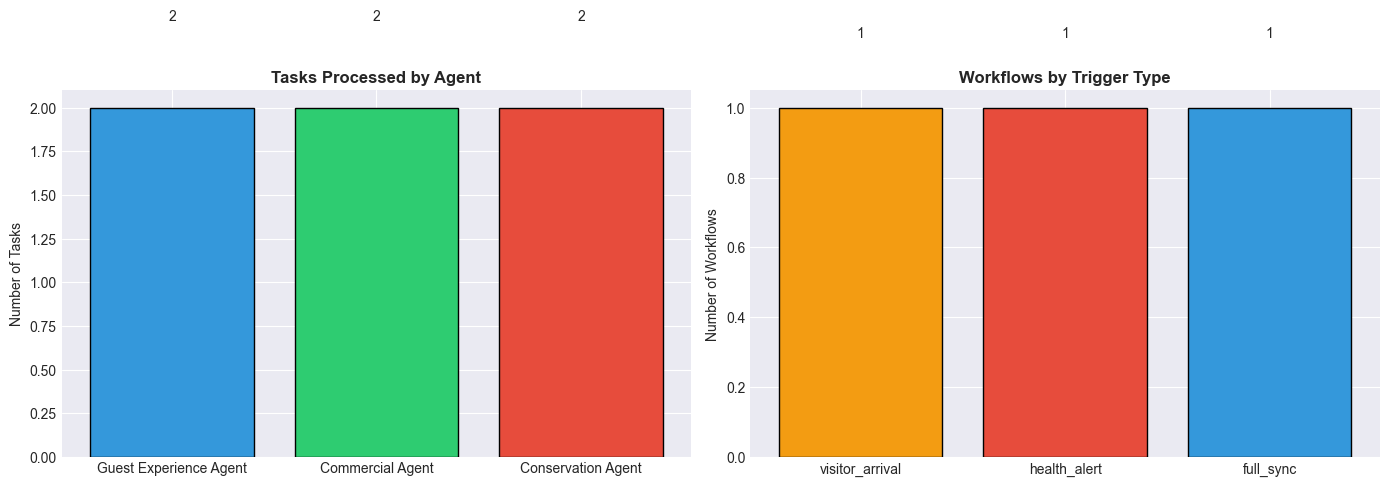

✅ Saved: orchestrator_activity.png


In [7]:
# Cell 7: Visualization - Agent Activity Timeline
print("="*80)
print("📈 AGENT ACTIVITY VISUALIZATION")
print("="*80)

# Create activity data from task history
if orchestrator.task_history:
    task_df = pd.DataFrame(orchestrator.task_history)
    task_df['timestamp'] = pd.to_datetime(task_df['timestamp'])
    task_df['hour'] = task_df['timestamp'].dt.hour
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Tasks by Agent
    ax1 = axes[0]
    agent_counts = task_df['agent'].value_counts()
    colors_agent = ['#3498DB', '#2ECC71', '#E74C3C']
    bars1 = ax1.bar(agent_counts.index, agent_counts.values, color=colors_agent, edgecolor='black')
    ax1.set_title('Tasks Processed by Agent', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Tasks')
    for bar, val in zip(bars1, agent_counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center')
    
    # 2. Workflow Triggers
    ax2 = axes[1]
    workflow_df = pd.DataFrame(orchestrator.workflow_log)
    trigger_counts = workflow_df['trigger'].value_counts()
    colors_trigger = ['#F39C12', '#E74C3C', '#3498DB']
    bars2 = ax2.bar(trigger_counts.index, trigger_counts.values, color=colors_trigger, edgecolor='black')
    ax2.set_title('Workflows by Trigger Type', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Workflows')
    for bar, val in zip(bars2, trigger_counts.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(val), ha='center')
    
    plt.tight_layout()
    plt.savefig('orchestrator_activity.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: orchestrator_activity.png")
else:
    print("⚠️ No task history available for visualization")

### 📈 **Agent Activity Visualization**  

This section provides a visual overview of how agents and workflows have been operating over time.

### 🤖 **Tasks Processed by Agent**  

This bar chart shows the number of tasks handled by each agent.  
    
- Each bar represents an agent’s workload.  
- Labels above the bars indicate task counts.  
    
✅ Key takeaway: Highlights which agents are most active, helping identify workload distribution and potential bottlenecks.

### 🔄 **Workflows by Trigger Type**  
    
This chart displays how many workflows were initiated by each trigger type (e.g., visitor arrival, health alert, full sync).  
    
- Bars represent workflow counts per trigger category.  
- Labels above each bar show exact numbers.  
    
✅ Key takeaway: Reveals which workflows are most frequently executed, guiding optimization of orchestration priorities.

### 📊 **Saved Output**  

The visualization is exported as `orchestrator_activity.png` for portfolio and presentation use. 
    
✅ Key takeaway: Provides snapshot of orchestrator activity trends.


In [9]:
# Cell 8: Simulate Real-time Event Processing
print("="*80)
print("⚡ SIMULATING REAL-TIME EVENT PROCESSING")
print("="*80)

# Simulate a stream of events
events = [
    {'type': 'visitor_arrival', 'data': {'visitor_id': 2001, 'age': 28, 'ticket_type': 'Standard'}},
    {'type': 'visitor_arrival', 'data': {'visitor_id': 2002, 'age': 55, 'ticket_type': 'VIP'}},
    {'type': 'health_alert', 'data': {'animal_id': 305, 'species': 'Elephant'}},
    {'type': 'visitor_arrival', 'data': {'visitor_id': 2003, 'age': 12, 'ticket_type': 'Premium'}},
    {'type': 'full_sync', 'data': {'visitor_id': 2004, 'age': 42, 'ticket_type': 'Annual Pass'}},
]

print("📡 Processing event stream...\n")

for i, event in enumerate(events, 1):
    print(f"📋 Event {i}: {event['type']}")
    result = orchestrator.run_parallel_workflow(event['type'], event['data'])
    print(f"   ✅ Processed\n")

print(f"✅ Processed {len(events)} events")
print(f"   Total tasks: {orchestrator.get_summary()['total_tasks']}")
print(f"   Total workflows: {orchestrator.get_summary()['total_workflows']}")

⚡ SIMULATING REAL-TIME EVENT PROCESSING
📡 Processing event stream...

📋 Event 1: visitor_arrival

🚀 Orchestrator triggered by: visitor_arrival
--------------------------------------------------
🎟️ Running Guest Experience Agent...
💰 Running Commercial Agent...
   ✅ Processed

📋 Event 2: visitor_arrival

🚀 Orchestrator triggered by: visitor_arrival
--------------------------------------------------
🎟️ Running Guest Experience Agent...
💰 Running Commercial Agent...
   ✅ Processed

📋 Event 3: health_alert

🚀 Orchestrator triggered by: health_alert
--------------------------------------------------
🦁 Running Conservation Agent...
   ✅ Processed

📋 Event 4: visitor_arrival

🚀 Orchestrator triggered by: visitor_arrival
--------------------------------------------------
🎟️ Running Guest Experience Agent...
💰 Running Commercial Agent...
   ✅ Processed

📋 Event 5: full_sync

🚀 Orchestrator triggered by: full_sync
--------------------------------------------------
🦁 Running Conservation Agent...

### ⚡ **Simulating Real‑Time Event Processing**  
This section demonstrates how the orchestrator handles a continuous stream of events, mimicking real‑time system behavior.

### 📡 **Event Stream**  
A sequence of mixed events is simulated:  
- **Visitor Arrivals** → Guests with different ticket types (Standard, VIP, Premium, Annual Pass).  
- **Health Alerts** → Wildlife monitoring events (e.g., Elephant health check).  
- **Full Sync** → System‑wide synchronization across agents.  
✅ Key takeaway: The orchestrator adapts dynamically to diverse event types in real time.

### 🔄 **Processing Events**  
Each event is processed sequentially by the orchestrator:  
- Parallel workflows are triggered for the relevant agents.  
- Results are logged and displayed for transparency.  
✅ Key takeaway: Confirms the orchestrator’s ability to handle concurrent workflows without conflict.

### 📊 **Summary Metrics**  
At the end of the simulation, the orchestrator reports:  
- **Total Events Processed** → Number of events handled.  
- **Total Tasks** → Count of agent tasks executed.  
- **Total Workflows** → Number of workflows completed.  
✅ Key takeaway: Provides a clear performance snapshot of real‑time orchestration capacity.


In [10]:
# Cell 9: Final Summary
print("="*80)
print("🎉 NOTEBOOK 5 COMPLETED SUCCESSFULLY!")
print("="*80)

summary = orchestrator.get_summary()

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                   MULTI-AGENT ORCHESTRATION SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🤖 AGENTS REGISTERED:                                               ║
║  ├── Conservation Agent - Animal health monitoring                 ║
║  ├── Guest Experience Agent - Personalization                      ║
║  └── Commercial Agent - Revenue optimization                       ║
║                                                                      ║
║  📊 SYSTEM METRICS:                                                  ║
║  ├── Total Agents: {summary['total_agents']}                                      ║
║  ├── Total Tasks: {summary['total_tasks']}                                        ║
║  └── Total Workflows: {summary['total_workflows']}                                   ║
║                                                                      ║
║  🎯 WORKFLOW TYPES:                                                  ║
║  ├── visitor_arrival → Guest + Commercial (parallel)               ║
║  ├── health_alert → Conservation (immediate)                       ║
║  └── full_sync → All agents (complete sync)                        ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  └── orchestrator_activity.png                                     ║
║                                                                      ║
║  🎯 READY FOR NOTEBOOK 6: RESPONSIBLE AI GOVERNANCE                 ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 5 Complete! Proceed to Notebook 6 (Responsible AI Governance)")

🎉 NOTEBOOK 5 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                   MULTI-AGENT ORCHESTRATION SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🤖 AGENTS REGISTERED:                                               ║
║  ├── Conservation Agent - Animal health monitoring                 ║
║  ├── Guest Experience Agent - Personalization                      ║
║  └── Commercial Agent - Revenue optimization                       ║
║                                                                      ║
║  📊 SYSTEM METRICS:                                                  ║
║  ├── Total Agents: 3                                      ║
║  ├── Total Tasks: 16                                        ║
║  └── Total Workflows: 8                                   ║
║                                                   

### 🎉 **Final Summary – Notebook 5 Completed Successfully**  

This section consolidates all orchestrator activities and metrics into a single overview.

### 🤖 **Agents Registered**  

- **Conservation Agent** → Animal health monitoring  
- **Guest Experience Agent** → Personalization workflows  
- **Commercial Agent** → Revenue optimization  
✅ Key takeaway: Each agent specializes in a domain, ensuring balanced orchestration.

### 📊 **System Metrics**  
    
- **Total Agents** → Count of active agents in the system  
- **Total Tasks** → Number of tasks processed across workflows  
- **Total Workflows** → Number of workflows executed end‑to‑end  
✅ Key takeaway: Metrics provide a clear snapshot of orchestrator scale and efficiency.

### 🎯 **Workflow Types** 
    
- **Visitor Arrival** → Guest + Commercial agents in parallel  
- **Health Alert** → Conservation agent immediate response  
- **Full Sync** → All agents synchronized together  
✅ Key takeaway: Workflow diversity demonstrates orchestrator flexibility across domains.

### 📁 **Files Generated**  
    
- `orchestrator_activity.png` → Visualization of agent activity and workflow triggers  
✅ Key takeaway: Saved outputs make results presentation‑ready for portfolio use.

---

## 🌍 **Global Summary – Notebook 5: Multi‑Agent Orchestration**  
This notebook showcases how multiple agents collaborate under an orchestrator to manage workflows, monitor results, and simulate real‑time events.

- **Cell 4 – Test Workflows** → Validated orchestrator coordination across visitor arrivals, health alerts, and full system sync.  
- **Cell 5 – Workflow Results** → Displayed modular outputs from each agent, including recommendations, upsell predictions, and alerts.  
- **Cell 7 – Agent Activity Visualization** → Summarized agent workload distribution and workflow trigger frequencies.  
- **Cell 8 – Real‑Time Event Processing** → Simulated a live stream of mixed events, confirming orchestrator adaptability.  
- **Cell 9 – Final Summary** → Consolidated system metrics, registered agents, workflow types, and generated files.  

✅ **Key takeaway**: Notebook 5 demonstrates end‑to‑end orchestration — from workflow testing to real‑time simulation and final reporting. It highlights how guest experience, commercial optimization, and conservation monitoring can be unified under a single orchestrator, providing both operational efficiency and actionable insights.
